In [49]:
# Import Statements
import numpy as np
import matplotlib.pyplot as plt
import os, json, shutil
import argparse

# note : most functions needed for running this notebook can be found in tc_utils.
from tc_utils import *



big_data, data_dict = parse_raw('Stainless_Steel_310', '/Users/ooriedesai/Documents/GitHub/Cryogenic_Material_Properties/thermal_conductivity/lib/Stainless_Steel_310/RAW', plots=True, weight_const=0.00)
T, k, koT, weights = [big_data[:,0], big_data[:,1], big_data[:,2], big_data[:,3]]


gaps = find_gaps(T, 100)
#print(find_gaps(T, 100), T[gaps])
maxT, minT = [max(T), min(T)]
fit_orders = [3,3]
fit_types = ["Nppoly", "polylog"]
def split_data(big_data, erf_loc):
    # divide the data array into three columns
    T, k, koT, weights = [big_data[:,0], big_data[:,1], big_data[:,2], big_data[:,3]]
    lowT, lowT_k, lowT_koT = [T[T<erf_loc], k[T<erf_loc], koT[T<erf_loc]]
    hiT, hiT_k, hiT_koT = [T[T>erf_loc], k[T>erf_loc], koT[T>erf_loc]]
    low_ws, hi_ws = [weights[T<erf_loc], weights[T>erf_loc]]
    #middleT, middleT_k, middleT_koT = [T[T==erf_loc], k[T==erf_loc], koT[T==erf_loc]]

    return [lowT, lowT_k, lowT_koT, low_ws, hiT, hiT_k, hiT_koT, hi_ws]

lowT, lowT_k, lowT_koT, low_ws, hiT, hiT_k, hiT_koT, hi_ws = split_data(big_data, T[gaps])

#print(np.argmax(lowT),np.argmin(hiT))
start_xs, end_xs = lowT[np.argmax(lowT)], hiT[np.argmin(hiT)]
start_y, end_y = lowT_k[np.argmax(lowT)], hiT_k[np.argmin(hiT)]
middleT = np.linspace(start_xs,end_xs,100)
middleT_k = np.linspace(start_y,end_y,100)
a = [start_xs, end_xs]
b = [start_y, end_y]
middle_fit = np.interp(middleT,a,b)
#print(hiT,hiT_k)
#print(middleT,middle_fit)

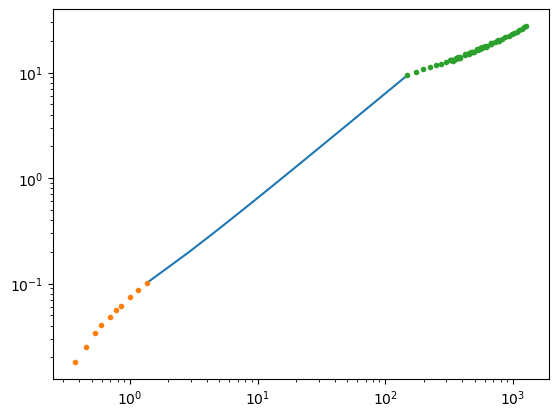

In [50]:
plt.plot(middleT,middle_fit)
plt.plot(lowT, lowT_k,'.')
plt.plot(hiT, hiT_k,'.')
plt.semilogx()
plt.semilogy()
plt.show()

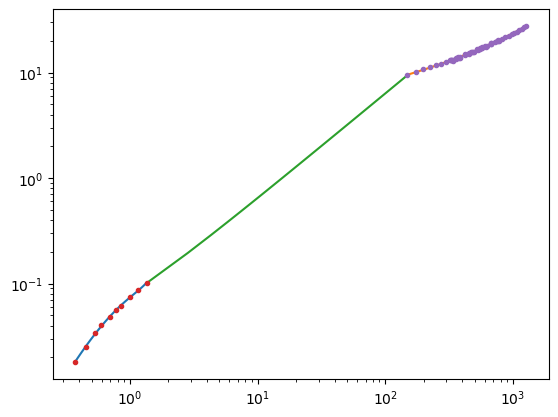

In [51]:
dsplit = split_data(big_data, T[gaps])
lowT, lowT_k, lowT_koT, low_ws, hiT, hiT_k, hiT_koT, hi_ws = dsplit

# Take a log10 of the high range
log_hi_T = np.log10(hiT)
log_hi_k = np.log10(hiT_k)
# Fit the low data
try:
    if (fit_types[0] == "Nppoly") and (len(lowT)!=0):
        low_fit_xs, low_fit = koT_function(lowT, lowT_koT, fit_orders[0], low_ws)
    elif (len(lowT)==0):
        low_fit = [0]
        low_fit_xs = [0]

    # Fit the high data
        
    if fit_types[1] == "polylog" and (len(hiT)!=0):
        hi_fit_xs, hi_fit = logk_function(log_hi_T, log_hi_k, fit_orders[1], hi_ws)
    elif (len(hiT)==0):
        hi_fit = [0]
        hi_fit_xs = [0]

except np.linalg.LinAlgError:
    print("LinAlgError - likely not enough points after weight to fit the data.")
    raise np.linalg.LinAlgError()
    
plt.plot(low_fit_xs, low_fit_xs*np.polyval(low_fit, low_fit_xs))
plt.loglog(10**hi_fit_xs, 10**np.polyval(hi_fit, hi_fit_xs))
plt.plot(middleT,middle_fit)
plt.plot(lowT, lowT_k,'.')
plt.plot(hiT, hiT_k,'.')
plt.semilogx()
plt.semilogy()
plt.show()